# EEG Data Preprocessing

This project performs preprocessing on EEG motor imagery dataset.

## Steps:
- Notch Filtering
- Bandpass Filtering
- Segmentation
- Normalization
- Label Creation

## Tools:
- Python
- MNE
- NumPy
- Scikit-learn

In [1]:
!pip install mne kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.1 MB/s eta 0:00:00


In [4]:
import os

os.environ['KAGGLE_USERNAME'] = 'yuvikaagarwal2105'
os.environ['KAGGLE_KEY'] = 'KGAT_945517875de4b2e3ee830b5e3ce65707'

In [5]:
!kaggle datasets download -d brianleung2020/eeg-motor-movementimagery-dataset

Dataset URL: https://www.kaggle.com/datasets/brianleung2020/eeg-motor-movementimagery-dataset
License(s): unknown
100% 1.87G/1.87G [00:25<00:00, 78.4MB/s]



In [6]:
!unzip eeg-motor-movementimagery-dataset.zip

Archive:  eeg-motor-movementimagery-dataset.zip
  inflating: files/64_channel_sharbrough-old.png  
  inflating: files/64_channel_sharbrough.pdf  
  inflating: files/64_channel_sharbrough.png  
  inflating: files/ANNOTATORS        
  inflating: files/RECORDS           
  inflating: files/S001/S001R01.edf  
  inflating: files/S001/S001R01.edf.event  
  inflating: files/S001/S001R02.edf  
  inflating: files/S001/S001R02.edf.event  
  inflating: files/S001/S001R03.edf  
  inflating: files/S001/S001R03.edf.event  
  inflating: files/S001/S001R04.edf  
  inflating: files/S001/S001R04.edf.event  
  inflating: files/S001/S001R05.edf  
  inflating: files/S001/S001R05.edf.event  
  inflating: files/S001/S001R06.edf  
  inflating: files/S001/S001R06.edf.event  
  inflating: files/S001/S001R07.edf  
  inflating: files/S001/S001R07.edf.event  
  inflating: files/S001/S001R08.edf  
  inflating: files/S001/S001R08.edf.event  
  inflating: files/S001/S001R09.edf  
  inflating: files/S001/S001R09.edf.e

In [7]:
import mne

file = "files/S001/S001R04.edf"
raw = mne.io.read_raw_edf(file, preload=True)

print(raw.info)

Extracting EDF parameters from files/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Using matplotlib as 2D backend.


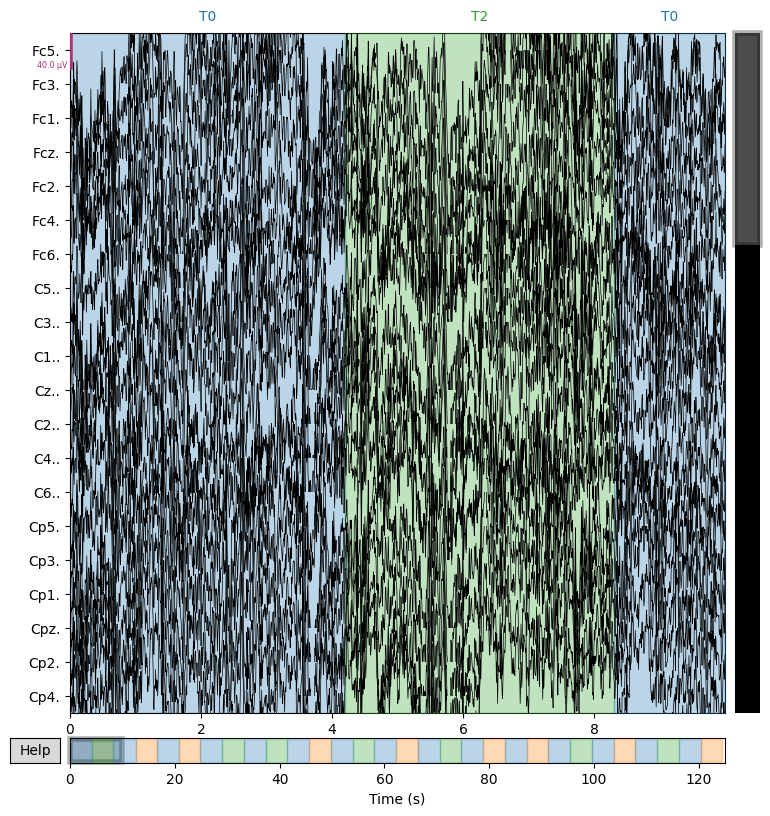

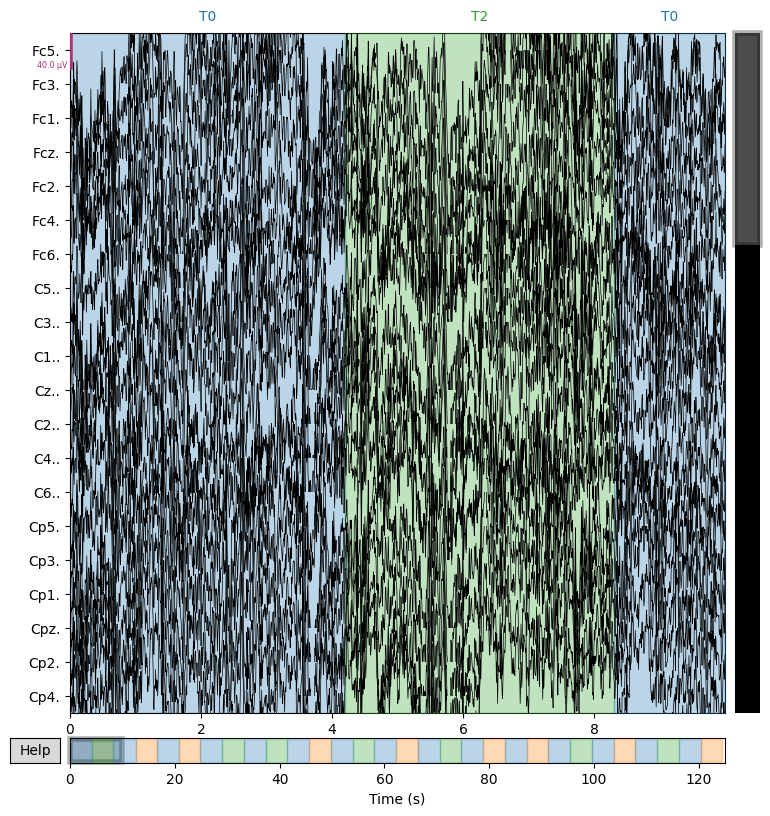

In [8]:
raw.plot()

In [9]:
raw.filter(7., 30.)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [10]:
raw.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1057 samples (6.606 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [12]:
events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(raw, events, event_id=event_id,
                    tmin=0, tmax=4, baseline=None)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


In [13]:
import numpy as np

X = epochs.get_data()

X = (X - np.mean(X)) / np.std(X)

Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


In [14]:
events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(raw, events, event_id=event_id,
                    tmin=0, tmax=4, baseline=None)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


In [15]:
y = epochs.events[:, -1]

print(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

[1 3 1 2 1 2 1 3 1 3 1 2 1 3 1 2 1 3 1 2 1 2 1 3 1 2 1 3 1 2]
X shape: (30, 64, 641)
y shape: (30,)


In [16]:
y = y - np.min(y)